# Clustering Analysis

Comobinaciones a tener en cuenta:

- Datos:
  
  1. scores discursivos --> Nuestras propuestas
  2. embeddings
  3. 1. + 2.
  3. 1. + scores reddit
  4. 3. + scores reddit

- Modelos:

  I. Nuestras propuestas --> (Fold) Fast Kmedoids con 1., 3., 4. y 5.
  II. Propuesta clásica --> KMeans con 2.


In [28]:
import os, sys
import polars as pl
from db_robust_clust.models import SampleDistClustering, FoldSampleDistClustering
from db_robust_clust.plots import clustering_MDS_plot_one_method
from kmedoids import KMedoids
from sklearn.manifold import MDS

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')

sys.path.append(project_path)

from src.utils.data_analysis_utils import (
    plot_quant_comparison,
    plot_cat_comparison
)

processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
processed_data = pl.read_parquet(processed_data_path)

In [29]:
KMEDOIDS_METHOD = 'pam'
METRIC = 'ggower'
D1 = 'robust_mahalanobis'
D2 = 'sokal'
D3 = 'hamming'

FRAC_SAMPLE_SIZE = 0.1
N_SPLITS = 5

clust_labels = {}

In [30]:
n_clusters = 3 

numerical_cols = [
    'sentiment_score'
]

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]


quant_cols = numerical_cols + ordinal_cols
binary_cols = []
multiclass_cols = nominal_cols 

p1 = len(quant_cols)
p2 = len(binary_cols)
p3 = len(multiclass_cols)

X = processed_data[quant_cols + binary_cols + multiclass_cols]

In [31]:
clustering_method = KMedoids(
    n_clusters=n_clusters, 
    metric='precomputed', 
    method=KMEDOIDS_METHOD, 
    init='build', 
    max_iter=100, 
    random_state=123
)

sample_dist_clust = SampleDistClustering(
    clustering_method = clustering_method,
    metric = METRIC,
    frac_sample_size=FRAC_SAMPLE_SIZE,
    random_state=123,
    stratify=False,
    p1=p1, p2=p2, p3=p3,
    d1=D1, d2=D2, d3=D3, 
    robust_method='trimmed', alpha=0.05
)

sample_dist_clust.fit(X)

,clustering_method,KMedoids(init...dom_state=123)
,metric,'ggower'
,frac_sample_size,0.1
,random_state,123
,stratify,False
,p1,3
,p2,0
,p3,2
,d1,'robust_mahalanobis'
,d2,'sokal'
,d3,'hamming'


In [32]:
fold_sample_dist_clust = FoldSampleDistClustering(
    clustering_method = clustering_method,
    metric = METRIC,
    n_splits=N_SPLITS, 
    shuffle=True,
    frac_sample_size=FRAC_SAMPLE_SIZE,
    meta_frac_sample_size=1,
    random_state=123,
    stratify=False,
    p1=p1, p2=p2, p3=p3,
    d1=D1, d2=D2, d3=D3, 
    robust_method='trimmed', alpha=0.05,
)

fold_sample_dist_clust.fit(X)

,clustering_method,KMedoids(init...dom_state=123)
,metric,'ggower'
,n_splits,5
,shuffle,True
,random_state,123
,stratify,False
,frac_sample_size,0.1
,meta_frac_sample_size,1
,p1,3
,p2,0
,p3,2


In [33]:
clust_labels[('sample_dist_clust', f'n_clusters={n_clusters}')] = sample_dist_clust.labels_
clust_labels[('fold_sample_dist_clust', f'n_clusters={n_clusters}')] = fold_sample_dist_clust.labels_

In [34]:
clust_labels

{('sample_dist_clust',
  'n_clusters=3'): array([1, 1, 0, ..., 0, 1, 0], dtype=uint64),
 ('fold_sample_dist_clust', 'n_clusters=3'): array([2, 2, 0, ..., 0, 2, 0])}

In [43]:
processed_data = processed_data.with_columns(
    pl.lit(clust_labels[(k1,k2)]).cast(pl.String).alias(f'labels{(k1,k2)}') for k1, k2 in clust_labels.keys()
)

In [36]:
D, D1, D2, D3 = sample_dist_clust.dist_output
sample_idx = sample_dist_clust.sample_idx

c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


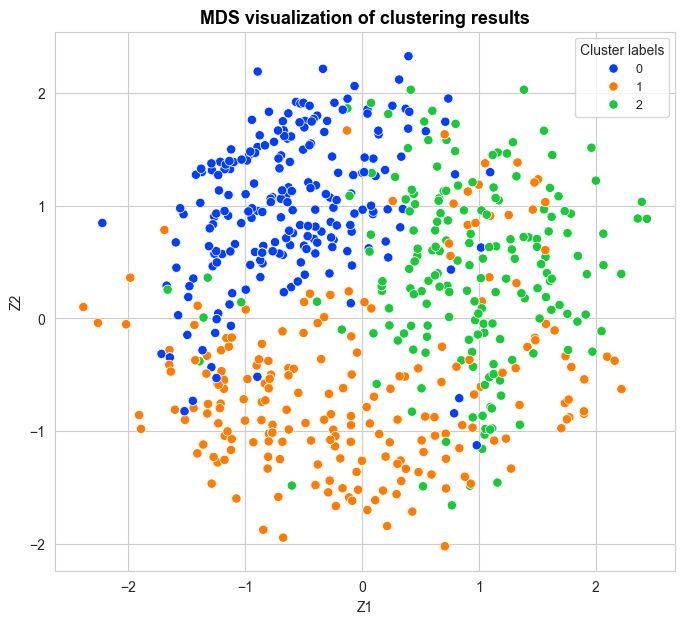

In [37]:
n_reduced = 1000

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=123) 

X_mds = mds.fit_transform(D[:n_reduced, :n_reduced])

clustering_MDS_plot_one_method(X_mds=X_mds, 
                               y_pred=clust_labels[('sample_dist_clust', 'n_clusters=3')][sample_idx[:n_reduced]], 
                               y_true=None, title="MDS visualization of clustering results", 
                               accuracy=None, time=None, 
                               figsize=(8,7), bbox_to_anchor=(1,1), 
                               title_size=13, title_weight='bold', 
                               points_size=45, title_height=1, 
                               save=False, legend_size=9)

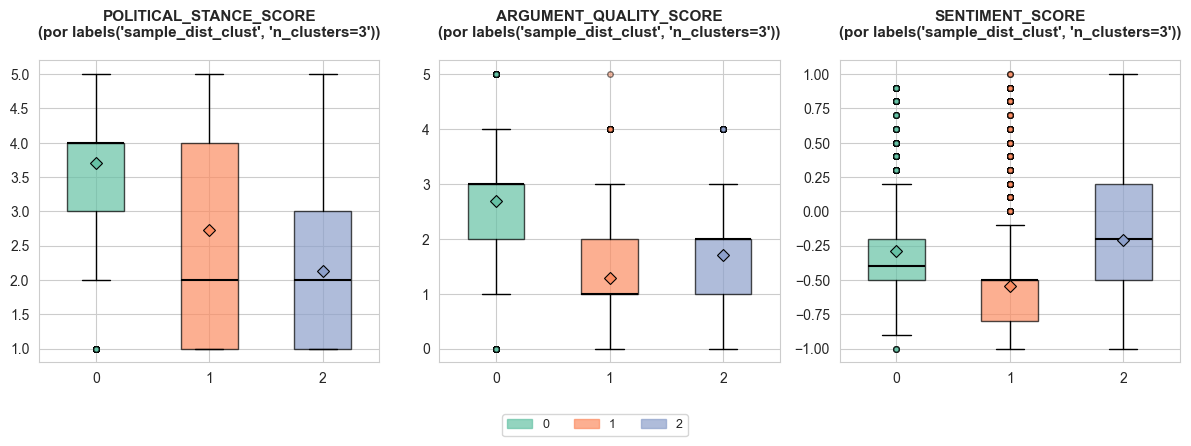

In [44]:
plot_quant_comparison(
    figsize=(12, 4),
    df=processed_data,
    comparisons=[
        ['political_stance_score'], ['argument_quality_score'], ['sentiment_score']
    ],
    group_by="labels('sample_dist_clust', 'n_clusters=3')",
    showfliers=True,
    title='',
    labelbottom=True,
    xlabel_rotation=0,
    bbox_to_anchor=(0.5, -0.12)
)

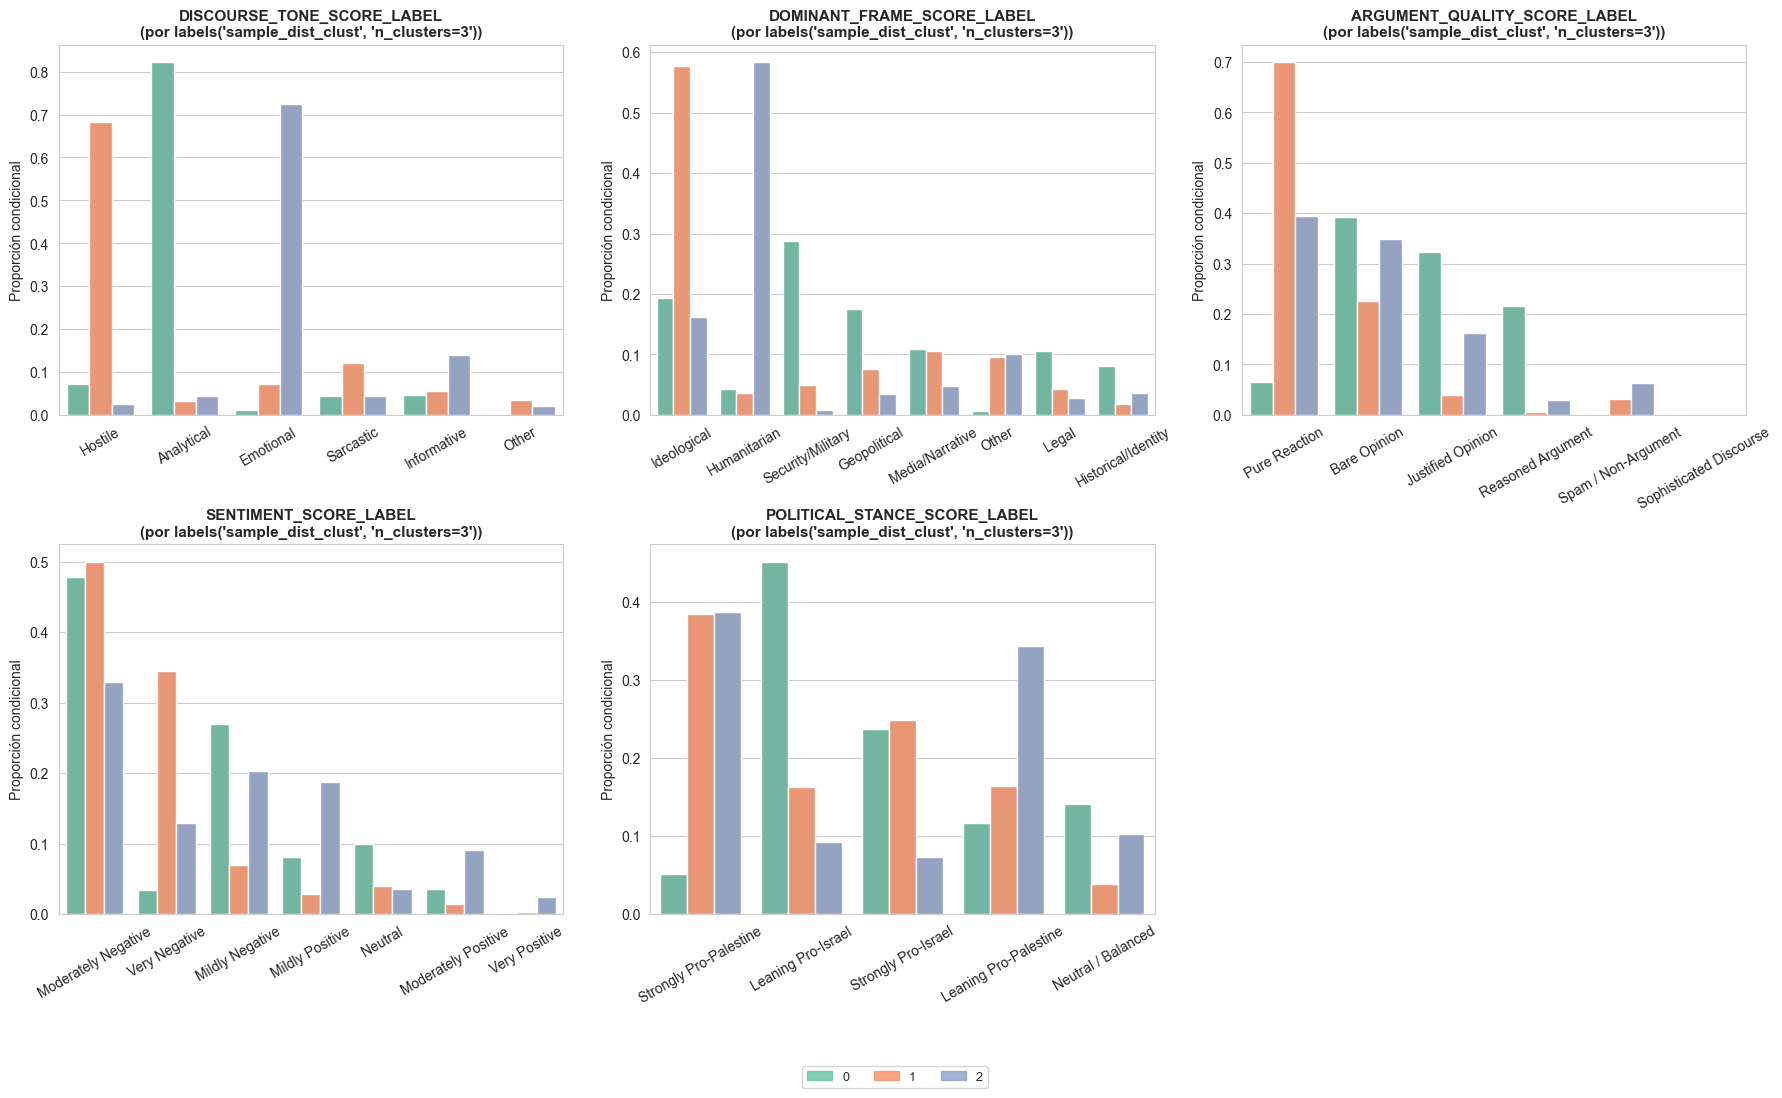

In [49]:
plot_cat_comparison(
    df=processed_data, 
    comparisons=[
        ['discourse_tone_score_label'], ['dominant_frame_score_label'], ['argument_quality_score_label'], ['sentiment_score_label'], ['political_stance_score_label']
    ], 
    title="",
    bbox_to_anchor=(0.5,-0.1),
    group_by="labels('sample_dist_clust', 'n_clusters=3')",
    max_cols=3,
    #x_rotation
    #orientation
)